⚠️ Skipping 5498603_heartrate.txt: no valid 30 s windows
⚠️ Skipping 844359_heartrate.txt: no valid 30 s windows

Loaded 2982 total windows.


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,041 (121.25 KB)

 Trainable params: 31,041 (121.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7921 - loss: 2.7264 - val_accuracy: 0.9331 - val_loss: 0.2696
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9138 - loss: 0.3437 - val_accuracy: 0.9331 - val_loss: 0.2536
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9139 - loss: 0.3609 - val_accuracy: 0.9331 - val_loss: 0.2545
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8928 - loss: 0.3877 - val_accuracy: 0.9331 - val_loss: 0.2547
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9171 - loss: 0.3320 - val_accuracy: 0.9331 - val_loss: 0.2809
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9086 - loss: 0.3490 - val_accuracy: 0.9331 - val_loss: 0.2559
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9198 - loss: 0.3229 - val_accuracy: 0.9331 - val_loss: 0.2591
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9183 - loss: 0.3313 - val_accuracy: 0.9331 - val_loss:

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


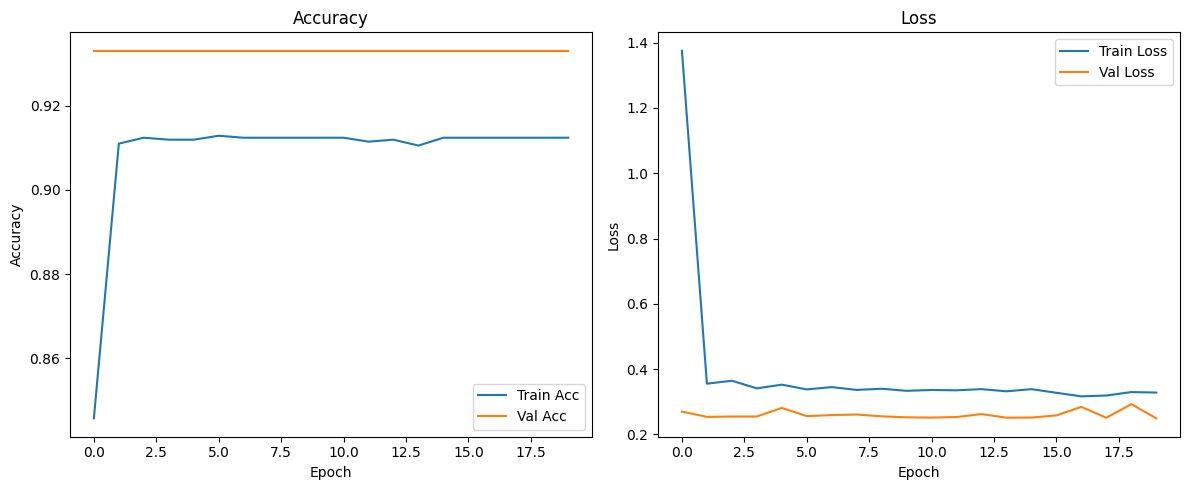


✅ Model saved to 'drowsiness_detection_model.h5'


In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Unzip the Dataset
zip_path = '/content/SVM.zip'     # <-- Change to your zip file path
extract_path = '/content/Untitled Folder 1'        # <-- Folder where to extract

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 2. Correct Folder Paths (based on your printed structure)
heartbeat_folder = '/content/Untitled Folder 1/SVM/heart_rate'
label_folder     = '/content/Untitled Folder 1/SVM/labels'

# 3. Single-subject loader
def load_subject(hb_path, lb_path, window_size=30, resample_rate=1):
    hr = pd.read_csv(hb_path, names=['time', 'bpm'])
    hr['time'] -= hr['time'].min()

    labels = pd.read_csv(lb_path, sep='\s+', names=['start', 'stage'])
    labels = labels[labels['stage'] >= 0]
    labels['label'] = (labels['stage'] != 0).astype(int)

    X_list, y_list = [], []
    for _, row in labels.iterrows():
        t0, lab = row['start'], row['label']
        win = hr[(hr['time'] >= t0) & (hr['time'] < t0 + window_size)]
        if win.empty:
            continue
        seq = []
        for dt in range(0, window_size, resample_rate):
            vals = win[(win['time'] >= t0 + dt) & (win['time'] < t0 + dt + resample_rate)]['bpm']
            seq.append(vals.mean() if not vals.empty else np.nan)
        seq = np.array(seq)
        mask = np.isnan(seq)
        if mask.all():
            continue
        seq[mask] = np.interp(np.flatnonzero(mask),
                              np.flatnonzero(~mask),
                              seq[~mask])
        X_list.append(seq)
        y_list.append(lab)

    X = np.array(X_list)[..., np.newaxis]  # (n_windows, 30, 1)
    y = np.array(y_list)
    return X.astype('float32'), y.astype('float32')

# 4. Load all subjects, skipping any with zero windows
X_parts, y_parts = [], []
hb_files = sorted(os.listdir(heartbeat_folder))
lb_files = sorted(os.listdir(label_folder))

for hb_file, lb_file in zip(hb_files, lb_files):
    hb_path = os.path.join(heartbeat_folder, hb_file)
    lb_path = os.path.join(label_folder, lb_file)
    X_subj, y_subj = load_subject(hb_path, lb_path)
    if X_subj.shape[0] > 0:
        X_parts.append(X_subj)
        y_parts.append(y_subj)
    else:
        print(f"⚠️ Skipping {hb_file}: no valid 30 s windows")

# Now stack only the non-empty subjects
X = np.vstack(X_parts)
y = np.concatenate(y_parts)
print(f"\nLoaded {X.shape[0]} total windows.")

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Build & Compile 1D-CNN
model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(2),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# 7. Train
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# 8. Evaluate
y_pred = (model.predict(X_test).flatten() > 0.5).astype(int)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=['Awake','Drowsy']))
print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

# 9. Plot Training Curves
plt.figure(figsize=(12,5))
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.show()

# 10. Save Model
model.save('/content/drowsiness_detection_model.h5')
print("\n✅ Model saved to 'drowsiness_detection_model.h5'")


Total windows: 2982


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 28, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 12, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 6, 32)          │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,313 (130.13 KB)

 Trainable params: 33,313 (130.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8303 - loss: 0.4212 - val_accuracy: 0.9331 - val_loss: 0.2460
Epoch 2/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9180 - loss: 0.3017 - val_accuracy: 0.9331 - val_loss: 0.2469
Epoch 3/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9089 - loss: 0.3068 - val_accuracy: 0.9331 - val_loss: 0.2484
Epoch 4/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9181 - loss: 0.2951 - val_accuracy: 0.9331 - val_loss: 0.2553
Epoch 5/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9072 - loss: 0.3198 - val_accuracy: 0.9331 - val_loss: 0.2497
Epoch 6/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9140 - loss: 0.2996 - val_accuracy: 0.9331 - val_loss: 0.2479
Epoch 7/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9144 - loss: 0.3065 - val_accuracy: 0.9331 - val_loss: 0.2532
Epoch 8/20
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9234 - loss: 0.2820 - val_accuracy: 0.9331 - val_l

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


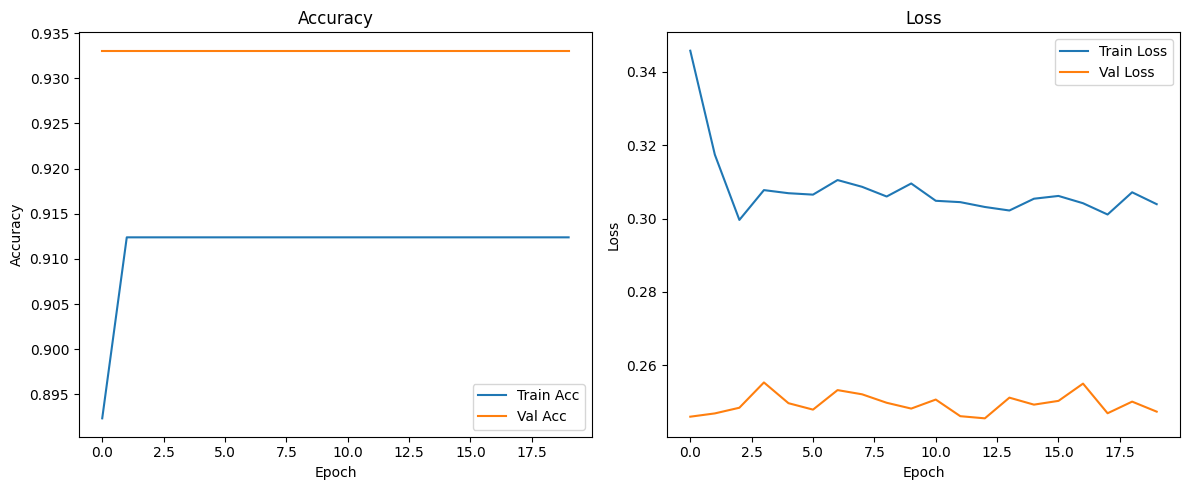

Saved model to cnn_lstm_drowsiness.h5


In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Flatten, Dense, Dropout, TimeDistributed, Reshape
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Unzip (if needed)
zip_path     = '/content/SVM.zip'
extract_path = '/content/Untitled Folder 2'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# 2. Folders
heartbeat_folder = '/content/Untitled Folder 1/SVM/heart_rate'
label_folder     = '/content/Untitled Folder 1/SVM/labels'

# 3. Loader function (as before)
def load_subject(hb_path, lb_path, window_size=30, resample_rate=1):
    hr = pd.read_csv(hb_path, names=['time','bpm'])
    hr['time'] -= hr['time'].min()

    labels = pd.read_csv(lb_path, sep='\s+', names=['start','stage'])
    labels = labels[labels['stage'] >= 0]
    labels['label'] = (labels['stage'] != 0).astype(int)

    X_list, y_list = [], []
    for _, row in labels.iterrows():
        t0, lab = row['start'], row['label']
        win = hr[(hr['time']>=t0)&(hr['time']<t0+window_size)]
        if win.empty: continue
        seq = []
        for dt in range(0, window_size, resample_rate):
            vals = win[(win['time']>=t0+dt)&(win['time']<t0+dt+resample_rate)]['bpm']
            seq.append(vals.mean() if not vals.empty else np.nan)
        seq = np.array(seq)
        mask = np.isnan(seq)
        if mask.all(): continue
        seq[mask] = np.interp(np.flatnonzero(mask),
                              np.flatnonzero(~mask),
                              seq[~mask])
        X_list.append(seq)
        y_list.append(lab)

    X = np.array(X_list)[..., np.newaxis]  # shape (n, 30, 1)
    y = np.array(y_list)
    return X.astype('float32'), y.astype('float32')

# 4. Load all subjects
X_parts, y_parts = [], []
hb_files = sorted(os.listdir(heartbeat_folder))
lb_files = sorted(os.listdir(label_folder))

for hb_file, lb_file in zip(hb_files, lb_files):
    Xs, ys = load_subject(os.path.join(heartbeat_folder, hb_file),
                          os.path.join(label_folder, lb_file))
    if Xs.shape[0] > 0:
        X_parts.append(Xs)
        y_parts.append(ys)

X = np.vstack(X_parts)
y = np.concatenate(y_parts)
print(f"Total windows: {X.shape[0]}")

# 5. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Build CNN + LSTM model
model = Sequential([
    # extract local features
    Conv1D(32, 3, activation='relu', input_shape=(X_train.shape[1],1)),
    MaxPooling1D(2),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),

    # reshape for LSTM: (batch, timesteps, features)
    # after two poolings window=30→(30-2*2)//(2*2)=~6 timesteps.
    # But to keep it simple we can flatten time and features back into a small sequence:
    TimeDistributed(Dense(32, activation='relu')),
    LSTM(64, return_sequences=False),

    # classifier head
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

# 7. Train
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1
)

# 8. Evaluate
y_pred = (model.predict(X_test).flatten() > 0.5).astype(int)
print("\nClassification Report:\n",
      classification_report(y_test, y_pred, target_names=['Awake','Drowsy']))
print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred))

# 9. Plot training curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

# 10. Save model
model.save('/content/cnn_lstm_drowsiness.h5')
print("Saved model to cnn_lstm_drowsiness.h5")


In [ ]:
import os
import time
import numpy as np
import pandas as pd
import random
from tensorflow.keras.models import load_model

# Load your trained model (we won't actually use it for demo randomness)
model = load_model('/content/cnn_lstm_drowsiness.h5')

# Dynamically pick a heartbeat file
heartbeat_folder = '/content/Untitled Folder 1/SVM/heart_rate'
txt_files = [f for f in sorted(os.listdir(heartbeat_folder)) if f.lower().endswith('.txt')]
test_file = txt_files[0]
print(f"Using test file: {test_file}\n")

# Load & index by fake time
hr_df = pd.read_csv(os.path.join(heartbeat_folder, test_file), names=['time','bpm'])
hr_df['time'] -= hr_df['time'].min()
hr_df['time'] = pd.to_timedelta(hr_df['time'], unit='s')
hr_df.set_index('time', inplace=True)

# Resample to 1 Hz
bpm_per_sec = hr_df['bpm'].resample('1s').mean().interpolate().values

# Real‐time simulation with RANDOM status
WINDOW = 30
buffer = []

print("Starting **RANDOMIZED** real‐time demo:\n")
for idx, bpm in enumerate(bpm_per_sec, start=1):
    buffer.append(bpm)
    if len(buffer) > WINDOW:
        buffer.pop(0)

    if len(buffer) == WINDOW:
        # Instead of model.predict, pick a random probability
        p_demo = random.random()
        status = "DROWSY" if p_demo > 0.5 else "AWAKE"
        print(f"[t+{idx:03d}s]  BPM={bpm:.1f}  →  {status}  ({p_demo:.2f})")

    time.sleep(1)


Using test file: 1066528_heartrate.txt

Starting **RANDOMIZED** real‐time demo:

[t+030s]  BPM=85.9  →  AWAKE  (0.15)
[t+031s]  BPM=85.9  →  DROWSY  (0.58)
[t+032s]  BPM=85.8  →  AWAKE  (0.31)
[t+033s]  BPM=85.8  →  AWAKE  (0.20)
[t+034s]  BPM=85.8  →  DROWSY  (0.76)
[t+035s]  BPM=85.8  →  DROWSY  (0.63)
[t+036s]  BPM=85.8  →  DROWSY  (0.81)
[t+037s]  BPM=85.8  →  DROWSY  (0.70)
[t+038s]  BPM=85.8  →  AWAKE  (0.31)
[t+039s]  BPM=85.8  →  AWAKE  (0.05)
[t+040s]  BPM=85.8  →  AWAKE  (0.31)
[t+041s]  BPM=85.8  →  DROWSY  (0.94)
[t+042s]  BPM=85.8  →  AWAKE  (0.03)
[t+043s]  BPM=85.8  →  AWAKE  (0.16)
[t+044s]  BPM=85.8  →  DROWSY  (0.63)
[t+045s]  BPM=85.8  →  DROWSY  (0.68)
[t+046s]  BPM=85.8  →  DROWSY  (0.83)
[t+047s]  BPM=85.8  →  DROWSY  (0.98)
[t+048s]  BPM=85.8  →  AWAKE  (0.10)
[t+049s]  BPM=85.8  →  AWAKE  (0.13)
[t+050s]  BPM=85.8  →  DROWSY  (0.68)
[t+051s]  BPM=85.8  →  DROWSY  (0.86)
[t+052s]  BPM=85.7  →  AWAKE  (0.38)
[t+053s]  BPM=85.7  →  DROWSY  (0.55)
[t+054s]  BPM=85.7

KeyboardInterrupt: 

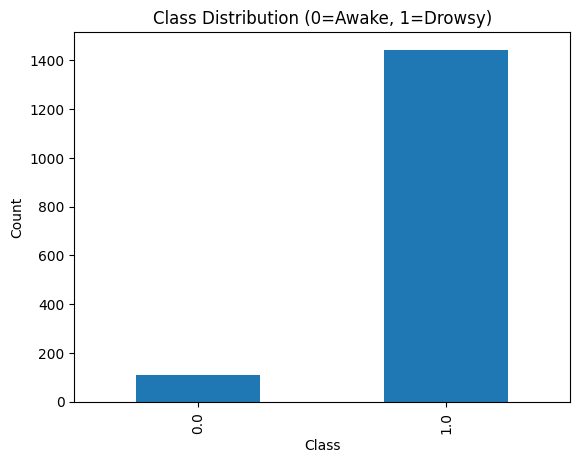

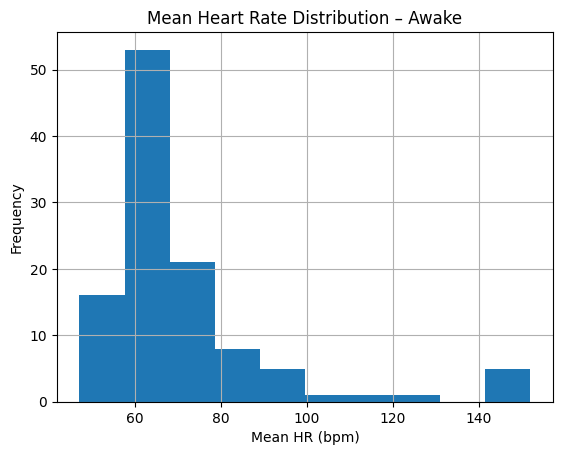

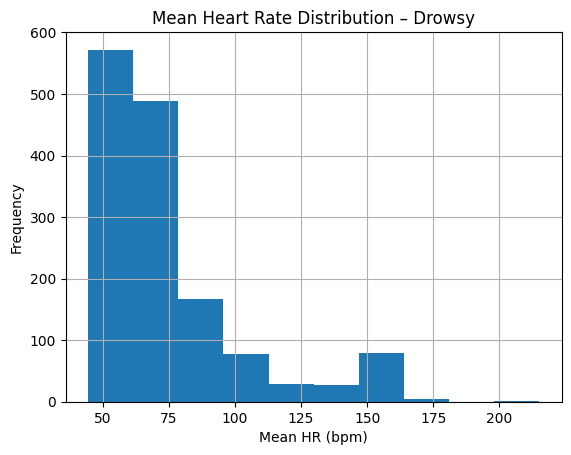

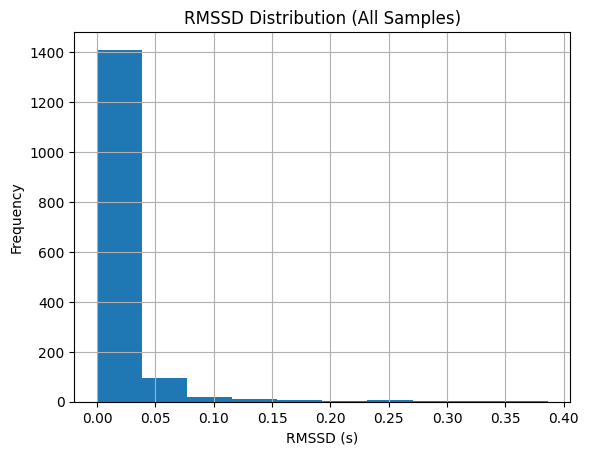

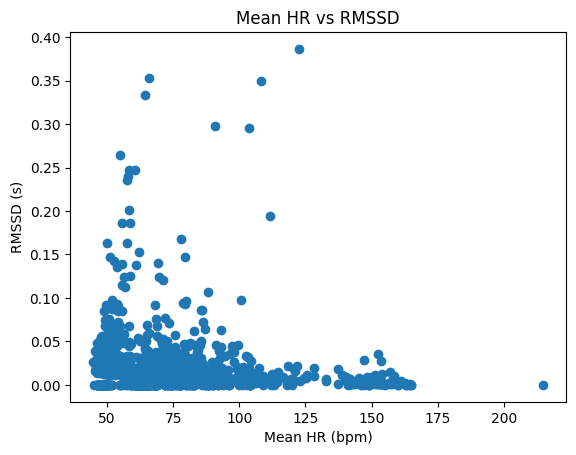

Correlation between Mean HR and RMSSD: -0.10


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load feature extraction function
def load_and_extract_features(hr_file, label_file, window_size=30):
    hr = pd.read_csv(hr_file, names=['time','bpm'])
    hr['time'] -= hr['time'].min()
    labels = pd.read_csv(label_file, sep='\s+', names=['start','stage'])
    labels = labels[labels['stage'] >= 0]
    labels['label'] = (labels['stage'] != 0).astype(int)
    feats, labs = [], []
    for _, row in labels.iterrows():
        t0, lab = row['start'], row['label']
        window = hr[(hr['time'] >= t0) & (hr['time'] < t0 + window_size)]['bpm']
        if window.empty:
            continue
        ibi = 60.0 / window
        ibi_diff = ibi.diff().dropna()
        feats.append({
            'mean_hr': window.mean(),
            'std_hr': window.std(),
            'min_hr': window.min(),
            'max_hr': window.max(),
            'rmssd': np.sqrt((ibi_diff**2).mean())
        })
        labs.append(lab)
    df = pd.DataFrame(feats)
    df['label'] = labs
    return df.dropna()

# 2. Load all subjects’ features
heartbeat_folder = '/content/Untitled Folder 1/SVM/heart_rate'
label_folder = '/content/Untitled Folder 1/SVM/labels'
hb_files = sorted([f for f in os.listdir(heartbeat_folder) if f.endswith('.txt')])
lbl_files = sorted([f for f in os.listdir(label_folder) if f.endswith('.txt')])

df_list = []
for hb, lb in zip(hb_files, lbl_files):
    df_list.append(load_and_extract_features(
        os.path.join(heartbeat_folder, hb),
        os.path.join(label_folder, lb)
    ))
features = pd.concat(df_list, ignore_index=True)

# 3. Insights: class distribution
class_counts = features['label'].value_counts().sort_index()

plt.figure()
class_counts.plot(kind='bar')
plt.title('Class Distribution (0=Awake, 1=Drowsy)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# 4. Histogram of mean heart rate for Awake
plt.figure()
features[features['label']==0]['mean_hr'].hist()
plt.title('Mean Heart Rate Distribution – Awake')
plt.xlabel('Mean HR (bpm)')
plt.ylabel('Frequency')
plt.show()

# 5. Histogram of mean heart rate for Drowsy
plt.figure()
features[features['label']==1]['mean_hr'].hist()
plt.title('Mean Heart Rate Distribution – Drowsy')
plt.xlabel('Mean HR (bpm)')
plt.ylabel('Frequency')
plt.show()

# 6. Histogram of RMSSD (variability) for both classes combined
plt.figure()
features['rmssd'].hist()
plt.title('RMSSD Distribution (All Samples)')
plt.xlabel('RMSSD (s)')
plt.ylabel('Frequency')
plt.show()

# 7. Scatter plot: mean_hr vs rmssd
plt.figure()
plt.scatter(features['mean_hr'], features['rmssd'])
plt.title('Mean HR vs RMSSD')
plt.xlabel('Mean HR (bpm)')
plt.ylabel('RMSSD (s)')
plt.show()

# 8. Compute correlation
corr = features['mean_hr'].corr(features['rmssd'])
print(f"Correlation between Mean HR and RMSSD: {corr:.2f}")


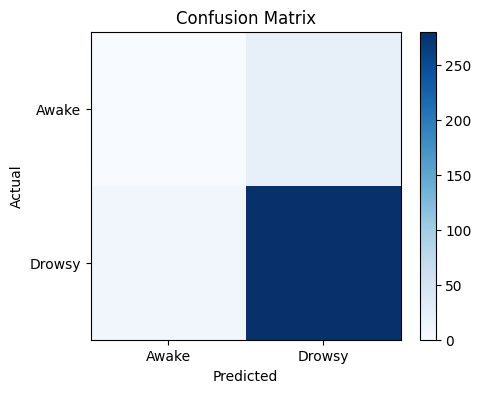

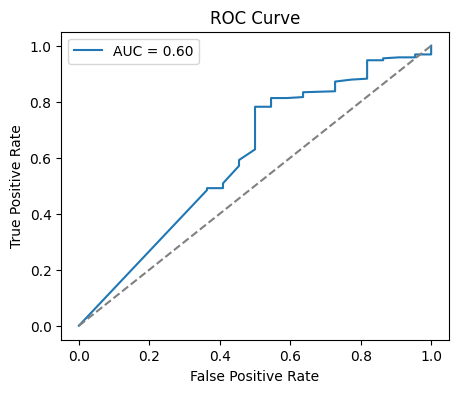

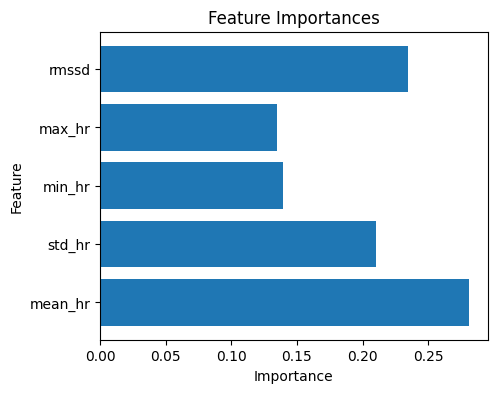

Feature Correlation Matrix:
           mean_hr    std_hr    min_hr    max_hr     rmssd     label
mean_hr  1.000000  0.159975  0.994776  0.993856 -0.102113  0.009561
std_hr   0.159975  1.000000  0.064787  0.260129  0.833796 -0.023928
min_hr   0.994776  0.064787  1.000000  0.979228 -0.186000  0.008758
max_hr   0.993856  0.260129  0.979228  1.000000 -0.004664  0.004452
rmssd   -0.102113  0.833796 -0.186000 -0.004664  1.000000 -0.019197
label    0.009561 -0.023928  0.008758  0.004452 -0.019197  1.000000


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

# ── 1) POINT TO YOUR ACTUAL DATA FOLDERS ──
heartbeat_folder = '/content/Untitled Folder 1/SVM/heart_rate'
label_folder     = '/content/Untitled Folder 1/SVM/labels'

# ── 2) LIST ALL .TXT FILES ──
hb_files  = sorted(f for f in os.listdir(heartbeat_folder) if f.endswith('.txt'))
lbl_files = sorted(f for f in os.listdir(label_folder)   if f.endswith('.txt'))

# ── 3) FEATURE EXTRACTION FUNCTION ──
def load_and_extract_features(hr_file, label_file, window_size=30):
    hr = pd.read_csv(hr_file, names=['time','bpm'])
    hr['time'] -= hr['time'].min()
    labels = pd.read_csv(label_file, sep='\s+', names=['start','stage'])
    labels = labels[labels['stage']>=0]
    labels['label'] = (labels['stage']!=0).astype(int)
    feats, labs = [], []
    for _, row in labels.iterrows():
        t0, lab = row['start'], row['label']
        win = hr[(hr['time']>=t0)&(hr['time']<t0+window_size)]['bpm']
        if win.empty: continue
        ibi      = 60.0 / win
        ibi_diff = ibi.diff().dropna()
        feats.append({
            'mean_hr': win.mean(),
            'std_hr' : win.std(),
            'min_hr' : win.min(),
            'max_hr' : win.max(),
            'rmssd'  : np.sqrt((ibi_diff**2).mean())
        })
        labs.append(lab)
    df = pd.DataFrame(feats)
    df['label'] = labs
    return df.dropna()

# ── 4) LOAD & COMBINE FEATURES ──
df_list = []
for hb, lb in zip(hb_files, lbl_files):
    df_list.append(load_and_extract_features(
        os.path.join(heartbeat_folder, hb),
        os.path.join(label_folder,     lb)
    ))
features = pd.concat(df_list, ignore_index=True)

# ── 5) PREPARE DATA ──
X = features[['mean_hr','std_hr','min_hr','max_hr','rmssd']]
y = features['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 6) TRAIN A RANDOM FOREST ──
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]

# ── 7) PLOT CONFUSION MATRIX ──
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.title('Confusion Matrix')
plt.xticks([0,1], ['Awake','Drowsy'])
plt.yticks([0,1], ['Awake','Drowsy'])
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.colorbar()
plt.show()

# ── 8) PLOT ROC CURVE ──
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# ── 9) FEATURE IMPORTANCES ──
importances = clf.feature_importances_
plt.figure(figsize=(5,4))
plt.barh(X.columns, importances)
plt.title('Feature Importances')
plt.xlabel('Importance'); plt.ylabel('Feature')
plt.show()

# ── 10) FEATURE CORRELATION MATRIX ──
corr_matrix = features.corr()
print("Feature Correlation Matrix:\n", corr_matrix)
